<a href="https://colab.research.google.com/github/hcopley/st_542_ml_systematic_review/blob/main/SuperLearnerD2V.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the SuperLearner package
install.packages("SuperLearner")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bitops’, ‘gtools’, ‘caTools’, ‘iterators’, ‘gplots’, ‘foreach’, ‘ROCR’, ‘nnls’, ‘gam’, ‘cvAUC’




In [20]:
# Install other packages
install.packages(c("xgboost", "randomForest", "e1071", "glmnet", "ranger"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [21]:
# Load libraries
library(SuperLearner)
library(xgboost)
library(randomForest)
library(e1071)
library(glmnet)

In [22]:
# Set seed to ensure reproducibility
set.seed(542)

In [23]:

# Load the data
data <- readRDS("doc2vec_dtst.rds")
valid_folds <- readRDS("cv_folds.rds")

In [24]:

# Separate features (X) and label (Y)
Y <- data[, 2]
X <- data[, -2]

In [25]:
# Define the learners
library_names <- c("SL.glm",       # Logistic Regression
                   "SL.svm",       # Support Vector Machine
                   "SL.xgboost",   # XGBoost
                   "SL.ranger",    # Random Forest
                   "SL.naivebayes")# Naive Bayes

# Customize SVM for classification if needed
SL.svm.class <- function(..., kernel = "radial") SL.svm(..., kernel = kernel)


In [28]:
# 5. Run CV.SuperLearner with custom folds
# This fits SL, then evaluates it using the 5-fold structure in valid_folds
set.seed(542) # For reproducibility
cv_sl <- CV.SuperLearner(Y = Y,
                         X = X,
                         family = binomial(), # Or gaussian() for regression
                         SL.library = library_names[!library_names %in% c("SL.svm", "SL.naivebayes")], # Remove SL.svm due to 'infeasible nu' error and SL.naivebayes for 'object not found'
                         cvControl = list(V = 5, validRows = valid_folds),
                         innerCvControl = list(list(V = 5)),
                         verbose = TRUE)

Warning message in CV.SuperLearner(Y = Y, X = X, family = binomial(), SL.library = library_names[!library_names %in% :
“Only a single innerCvControl is given, will be replicated across all cross-validation split calls to SuperLearner”
Number of covariates in All is: 101

CV SL.glm_All

CV SL.xgboost_All



Growing trees.. Progress: 61%. Estimated remaining time: 19 seconds.


CV SL.ranger_All

Number of covariates in All is: 101

CV SL.glm_All

CV SL.xgboost_All



Growing trees.. Progress: 65%. Estimated remaining time: 16 seconds.


CV SL.ranger_All

Number of covariates in All is: 101

CV SL.glm_All

CV SL.xgboost_All



...

CV SL.ranger_All

Number of covariates in All is: 101

CV SL.glm_All

CV SL.xgboost_All



Growing trees.. Progress: 66%. Estimated remaining time: 16 seconds.


CV SL.ranger_All

Non-Negative least squares convergence: TRUE

full SL.glm_All

full SL.xgboost_All



Growing trees.. Progress: 46%. Estimated remaining time: 36 seconds.
Growing trees.. Progress: 92%. Estimated remaining time: 5 seconds.


full SL.ranger_All




Call:  
CV.SuperLearner(Y = Y, X = X, family = binomial(), SL.library = library_names[!library_names %in%  
    c("SL.svm", "SL.naivebayes")], verbose = TRUE, cvControl = list(V = 5,  
    validRows = valid_folds), innerCvControl = list(list(V = 5))) 

Risk is based on: Mean Squared Error

All risk estimates are based on V =  5 

      Algorithm      Ave        se      Min      Max
  Super Learner 0.059748 0.0016299 0.052880 0.067350
    Discrete SL 0.062947 0.0017295 0.056375 0.070694
     SL.glm_All 0.062153 0.0015909 0.053937 0.070694
 SL.xgboost_All 0.063045 0.0017834 0.056375 0.071182
  SL.ranger_All 0.061348 0.0014647 0.056109 0.068016


Loading required namespace: ggplot2

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the SuperLearner package.
  Please report the issue to the authors.”


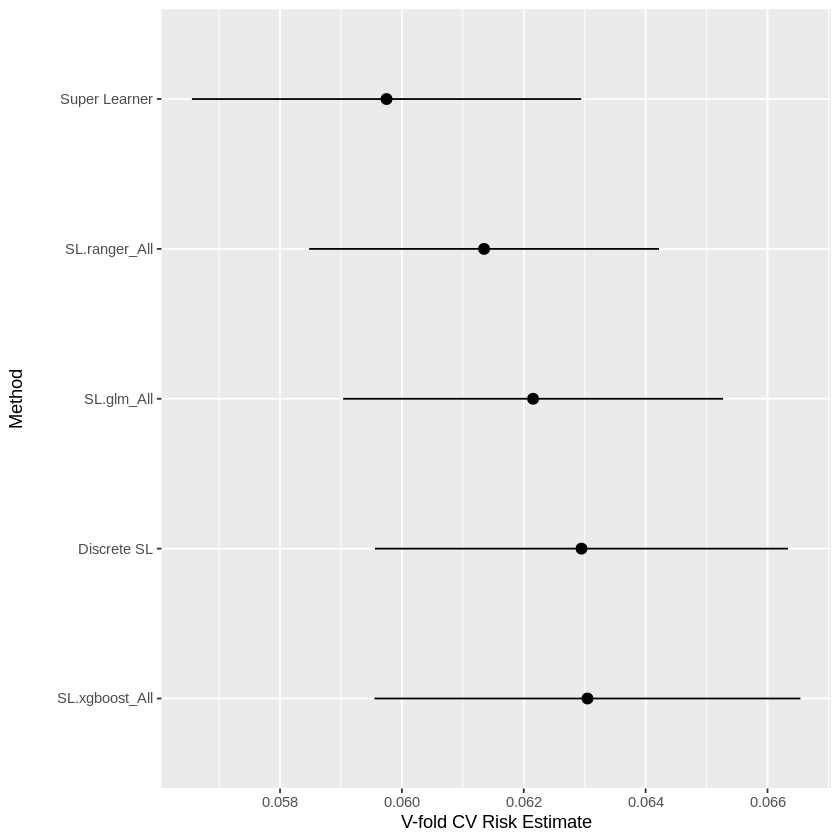

In [29]:
# Check the results
print(summary(cv_sl))
plot(cv_sl)

In [31]:
print(coef(cv_sl))

      SL.glm_All SL.xgboost_All SL.ranger_All
Fold1  0.2857147      0.4690101     0.2452752
Fold2  0.3003045      0.4980835     0.2016120
Fold3  0.2898302      0.4778532     0.2323166
Fold4  0.3010466      0.4689527     0.2300007
Fold5  0.3303353      0.4321273     0.2375374


In [34]:
# Run the SuperLearner fit the 5 pre-defined lists from cv_folds.rds
sl_fit <- SuperLearner(
  Y = Y,
  X = X,
  family = binomial(),
  SL.library = library_names[!library_names %in% c("SL.svm", "SL.naivebayes")],
  cvControl = list(
    V = 5,
    validRows = valid_folds
  )
)

# View the final weights
print(sl_fit)

# Print the weights
final_weights <- sl_fit$coef
print(final_weights)

Growing trees.. Progress: 37%. Estimated remaining time: 51 seconds.
Growing trees.. Progress: 75%. Estimated remaining time: 20 seconds.
Growing trees.. Progress: 39%. Estimated remaining time: 47 seconds.
Growing trees.. Progress: 78%. Estimated remaining time: 17 seconds.
Growing trees.. Progress: 36%. Estimated remaining time: 55 seconds.
Growing trees.. Progress: 72%. Estimated remaining time: 23 seconds.
Growing trees.. Progress: 39%. Estimated remaining time: 49 seconds.
Growing trees.. Progress: 76%. Estimated remaining time: 20 seconds.
Growing trees.. Progress: 37%. Estimated remaining time: 53 seconds.
Growing trees.. Progress: 73%. Estimated remaining time: 22 seconds.
Growing trees.. Progress: 27%. Estimated remaining time: 1 minute, 22 seconds.
Growing trees.. Progress: 55%. Estimated remaining time: 49 seconds.
Growing trees.. Progress: 86%. Estimated remaining time: 15 seconds.

Call:  
SuperLearner(Y = Y, X = X, family = binomial(), SL.library = library_names[!library_